# Feed Forward Network con PyTorch

El presente notebook corresponde a la primera tarea del segundo parcial de la materia de Inteligencia Computacional. Se entrenan tres modelos tipo red neuronal con el conjunto de datos MNIST. Se evalúa el mejor modelo con datos de prueba.

In [ ]:
# Imports

import numpy as np
import gzip
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
import torch
import torch.nn as nn
import numpy as np

## Cargar conjunto de datos MNIST

Para cargar los datos se utilizó como base el ejemplo proporcionado por el profesor.

In [15]:
def load_mnist_dataset(mnist_path):
    x_trainval = get_images(Path(mnist_path)/Path('train-images-idx3-ubyte.gz'))
    y_trainval = get_labels(Path(mnist_path)/Path('train-labels-idx1-ubyte.gz'))

    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]

    x_val = x_trainval[50000:]
    y_val = y_trainval[50000:]

    x_test = get_images(Path(mnist_path)/Path('t10k-images-idx3-ubyte.gz'))
    y_test = get_labels(Path(mnist_path)/Path('t10k-labels-idx1-ubyte.gz'))

    return x_train, y_train, x_val, y_val, x_test, y_test

def get_labels(path):
    with gzip.open(path, 'rb') as data:
        labels = data.read()[8:]
        return np.frombuffer(labels, dtype=np.uint8)

def get_images(path):
    with gzip.open(path, 'rb') as data:
        _ = int.from_bytes(data.read(4), 'big')
        num_images = int.from_bytes(data.read(4), 'big')
        rows = int.from_bytes(data.read(4), 'big')
        cols = int.from_bytes(data.read(4), 'big')
        images = data.read()
        return np.frombuffer(images, dtype=np.uint8).reshape((num_images, rows, cols))

In [16]:
# Cargar conjunto de datos

x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_dataset('data/mnist')

In [17]:
# Aplanar imágenes

x_train = x_train.copy().reshape(50000, -1).astype(np.float32)
y_train = y_train.copy().reshape(50000, 1)

x_val = x_val.copy().reshape(10000, -1).astype(np.float32)
y_val = y_val.copy().reshape(10000, 1)

x_test = x_test.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test.copy().reshape(10000, 1)


# Convertir a tensores

x_train = torch.tensor(x_train, dtype=torch.float32)
x_val   = torch.tensor(x_val, dtype=torch.float32)
x_test  = torch.tensor(x_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

In [18]:
# Función para mostrar una imágen del conjunto de datos

def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

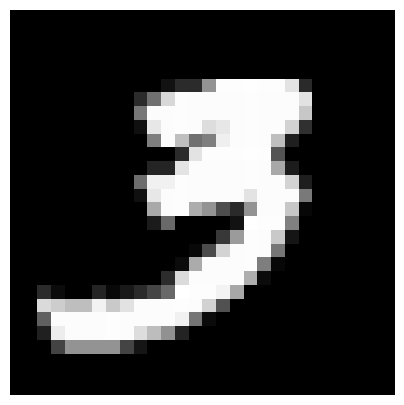

'Label: 3'

In [19]:
# Mostrar imágen aleatoria del conjunto de datos de entrenamiento

random_idx = np.random.randint(0, x_train.shape[0])
plot_number(x_train[random_idx])
display(f"Label: {y_train[random_idx].squeeze()}")

## Definición de los 3 modelos

In [ ]:
# Definir función de pérdida

loss_fn = nn.CrossEntropyLoss()

In [ ]:
# Modelo 1
model_1 = nn.Sequential(
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer_1 = torch.optim.SGD(model_1.parameters(), lr=0.01)
num_epochs_1 = 20

In [ ]:
# Modelo 2

model_2 = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer_2 = torch.optim.Adam(model_2.parameters(), lr=0.001)
num_epochs_2 = 15

In [ ]:
# Modelo 3

model_3 = nn.Sequential(
    nn.Linear(784, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

optimizer_3 = torch.optim.Adam(model_3.parameters(), lr=0.0005)
num_epochs_3 = 15

## Entrenamiento de los modelos

In [ ]:
# Modelo 1

In [ ]:
# Modelo 2

In [ ]:
# Modelo 3